In [ ]:
#@title Import Necessary Packages

import numpy as np
import pandas as pd
import matplotlib
import itertools
from matplotlib import pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error as mse
from scipy.optimize import minimize

# Import Models
from sklearn.linear_model import LinearRegression as lnr
from sklearn.svm import SVR as svr
from sklearn.tree import DecisionTreeRegressor as dtr
from sklearn.ensemble import RandomForestRegressor as rfr
from sklearn.ensemble import HistGradientBoostingRegressor as gbr
from sklearn.neighbors import KNeighborsRegressor as knr

In [ ]:
#@title Obtain Data

!wget https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv

--2026-08-13 00:06:01--  https://raw.githubusercontent.com/mhrafiei/data/main/concrete_compressive_strength.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.111.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.111.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 41747 (41K) [text/plain]
Saving to: ‘concrete_compressive_strength.csv’

concrete_compressiv 100%[===================>]  40.77K  --.-KB/s    in 0.03s   

2026-08-13 00:06:02 (1.30 MB/s) - ‘concrete_compressive_strength.csv’ saved [41747/41747]



In [ ]:
#@title Data Processing
data      = pd.read_csv('/content/concrete_compressive_strength.csv')

# only 28-day concrete strength
ind  = data['Age (day)'].values == 28
data = data.iloc[ind,:]
data = data.drop(['Age (day)'], axis = 1 )

# get all before first '(' for simplicity
data_keys = list(data.keys())
keys = []
for i0 in data_keys:
  keys.append(i0[:i0.find('(')])

datain = data.iloc[:,:-1]
dataou = data.iloc[:,-1:]

datain = datain.values
dataou = dataou.values

print("\nFirst five rows:")
display(data.head())

print("\nDataset information:")
data.info()


First five rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,61.89
7,380.0,95.0,0.0,228.0,0.0,932.0,594.0,36.45
8,266.0,114.0,0.0,228.0,0.0,932.0,670.0,45.85
9,475.0,0.0,0.0,228.0,0.0,932.0,594.0,39.29



Dataset information:
<class 'pandas.core.frame.DataFrame'>
Index: 425 entries, 0 to 1029
Data columns (total 8 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              425 non-null    float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  425 non-null    float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             425 non-null    float64
 3   Water  (component 4)(kg in a m^3 mixture)              425 non-null    float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    425 non-null    float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   425 non-null    float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      425 non-null    float64
 7   Concrete compressive strength(MPa, megapascals)        425 non-null    float64
dtypes: float64(8)
memory usage: 29.9 

In [ ]:
#@title Functions
def fun_split(RTT, RRS, num_data):
  np.random.seed(42)

  index_te = []
  index_tr = []

  for rtt in RTT:
    index_te_tmp = []
    index_tr_tmp = []

    for rrs in range(RRS):
      index = list(range(num_data))
      index = np.ndarray.tolist(np.random.permutation(index))

      index_te_tmp.append(index[0:int(np.floor(rtt*num_data))])
      index_tr_tmp.append(index[int(np.floor(rtt*num_data)):])

    index_te.append(index_te_tmp)
    index_tr.append(index_tr_tmp)

  return index_tr, index_te


def fun_prep(datain, dataou, index_tr, index_te, lb, ub):
  datain_tr = datain[index_tr, :]
  datain_te = datain[index_te, :]
  dataou_tr = dataou[index_tr,:]
  dataou_te = dataou[index_te,:]

  if len(datain_tr.shape) == 1:
    datain_tr = np.expand_dims(datain_tr, axis = 1)
    datain_te = np.expand_dims(datain_te, axis = 1)

  if len(dataou_tr.shape) == 1:
    dataou_tr = np.expand_dims(dataou_tr, axis = 1)
    dataou_te = np.expand_dims(dataou_te, axis = 1)

  scalerin = MinMaxScaler(feature_range=(lb,ub))
  scalerin.fit(datain_tr)

  scalerou = MinMaxScaler(feature_range=(lb,ub))
  scalerou.fit(dataou_tr)

  datain_tr_calibrated = scalerin.transform(datain_tr)
  datain_te_calibrated = scalerin.transform(datain_te)

  dataou_tr_calibrated = scalerou.transform(dataou_tr)
  dataou_te_calibrated = scalerou.transform(dataou_te)

  return datain_tr_calibrated, dataou_tr_calibrated, datain_te_calibrated, dataou_te_calibrated


def fun_ml(datain_tr, dataou_tr, datain_te, dataou_te, model_type):

  result = {}

  if model_type == 'LNR':
    mdl       = lnr()
  elif model_type == 'SVR':
    mdl       = svr()
  elif model_type == 'DTR':
    mdl       = dtr()
  elif model_type == 'RFR':
    mdl       = rfr()
  elif model_type == 'GDB':
    mdl       = gbr()
  elif model_type == 'KNN':
    mdl       = knr()
  else:
    print("Model type has not been defined!")

  result['model_type'] = model_type
  history              = mdl.fit(datain_tr, dataou_tr)
  dataes_tr            = mdl.predict(datain_tr)
  dataes_te            = mdl.predict(datain_te)
  result['mse_tr']     = mse(dataes_tr, dataou_tr)
  result['mse_te']     = mse(dataes_te, dataou_te)
  result['dataes_tr']  = dataes_tr
  result['dataes_te']  = dataes_te
  result['datain_tr']  = datain_tr
  result['datain_te']  = datain_te
  result['dataou_tr']  = dataou_tr
  result['dataou_te']  = dataou_te
  return result


In [ ]:
#@title Main run
import warnings
warnings.filterwarnings("ignore")

model_type = ['LNR', 'SVR', 'DTR', 'RFR', 'GDB', 'KNN']
RTT        = [0.05, 0.1]
RRS        = 10

# necessary information for combinatory model
num_data      = datain.shape[0]
num_variables = datain.shape[1]

index_tr, index_te           = fun_split(RTT, RRS, num_data)

result = np.empty((len(RTT), RRS, len(model_type)), dtype = dict)

counter = 1
for i1 in range(len(RTT)):
  for i2 in range(RRS):
    datain_tr, dataou_tr, datain_te, dataou_te = fun_prep(datain, dataou, index_tr[i1][i2], index_te[i1][i2], 0, 1)
    for i3 in range(len(model_type)):
      result[i1,i2,i3] = fun_ml(datain_tr, dataou_tr, datain_te, dataou_te, model_type[i3])
      print("RTT #: {:05d}/{} | RRS #: {:05d}/{} | Model: {} | Completed {:07.3F}%".format(i1+1, len(RTT), i2+1, RRS, model_type[i3], counter/(len(RTT) * RRS * len(model_type))*100))
      counter = counter + 1


RTT #: 00001/2 | RRS #: 00001/10 | Model: LNR | Completed 000.833%
RTT #: 00001/2 | RRS #: 00001/10 | Model: SVR | Completed 001.667%
RTT #: 00001/2 | RRS #: 00001/10 | Model: DTR | Completed 002.500%
RTT #: 00001/2 | RRS #: 00001/10 | Model: RFR | Completed 003.333%
RTT #: 00001/2 | RRS #: 00001/10 | Model: GDB | Completed 004.167%
RTT #: 00001/2 | RRS #: 00001/10 | Model: KNN | Completed 005.000%
RTT #: 00001/2 | RRS #: 00002/10 | Model: LNR | Completed 005.833%
RTT #: 00001/2 | RRS #: 00002/10 | Model: SVR | Completed 006.667%
RTT #: 00001/2 | RRS #: 00002/10 | Model: DTR | Completed 007.500%
RTT #: 00001/2 | RRS #: 00002/10 | Model: RFR | Completed 008.333%
RTT #: 00001/2 | RRS #: 00002/10 | Model: GDB | Completed 009.167%
RTT #: 00001/2 | RRS #: 00002/10 | Model: KNN | Completed 010.000%
RTT #: 00001/2 | RRS #: 00003/10 | Model: LNR | Completed 010.833%
RTT #: 00001/2 | RRS #: 00003/10 | Model: SVR | Completed 011.667%
RTT #: 00001/2 | RRS #: 00003/10 | Model: DTR | Completed 012.

In [ ]:
#@title Create MSE Table

rows = []

for i1 in range(len(RTT)):
  for i2 in range(RRS):
    for i3 in range(len(model_type)):
      curr = result[i1,i2,i3]

      rows.append({"Model": model_type[i3],
                   "RTT": RTT[i1],
                   "RRS": i2+1,
                   "MSE Training": curr["mse_tr"],
                   "MSE Testing": curr["mse_te"]
                   })
df = pd.DataFrame(rows)

display(df)
df.to_csv("MSE Table.csv", index=False)


df_grouped = df.sort_values(
    by=["Model", "RTT", "RRS"]
).reset_index(drop=True)

display(df_grouped)
df_grouped.to_csv("MSE_Table_Grouped_By_Model.csv", index=False)

,Model,RTT,RRS,MSE Training,MSE Testing
0,LNR,0.05,1,0.008918,0.014993
1,SVR,0.05,1,0.005273,0.008918
2,DTR,0.05,1,0.000039,0.003799
3,RFR,0.05,1,0.000893,0.005045
4,GDB,0.05,1,0.001175,0.004611
...,...,...,...,...,...
115,SVR,0.10,10,0.005303,0.007103
116,DTR,0.10,10,0.000042,0.008257
117,RFR,0.10,10,0.000948,0.004163
118,GDB,0.10,10,0.001265,0.003516


,Model,RTT,RRS,MSE Training,MSE Testing
0,DTR,0.05,1,0.000039,0.003799
1,DTR,0.05,2,0.000039,0.010464
2,DTR,0.05,3,0.000039,0.003811
3,DTR,0.05,4,0.000039,0.004999
4,DTR,0.05,5,0.000039,0.002191
...,...,...,...,...,...
115,SVR,0.10,6,0.005503,0.007701
116,SVR,0.10,7,0.005432,0.005661
117,SVR,0.10,8,0.005583,0.005501
118,SVR,0.10,9,0.005683,0.007553


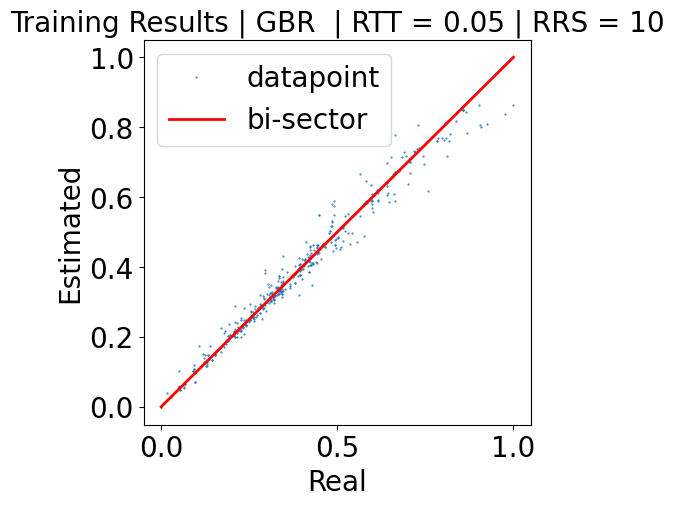

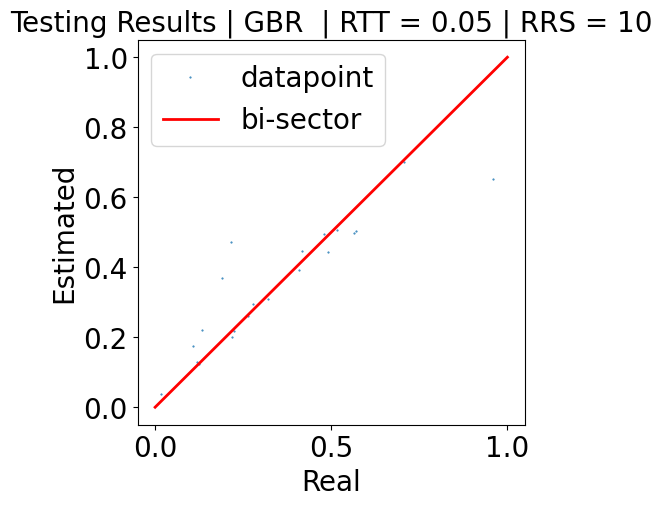

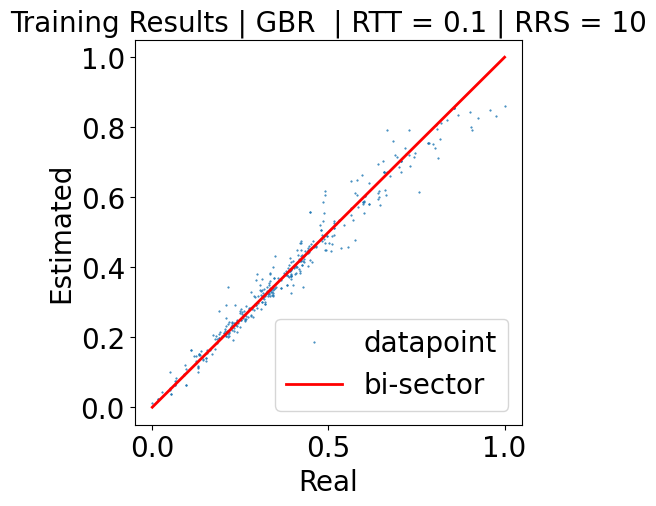

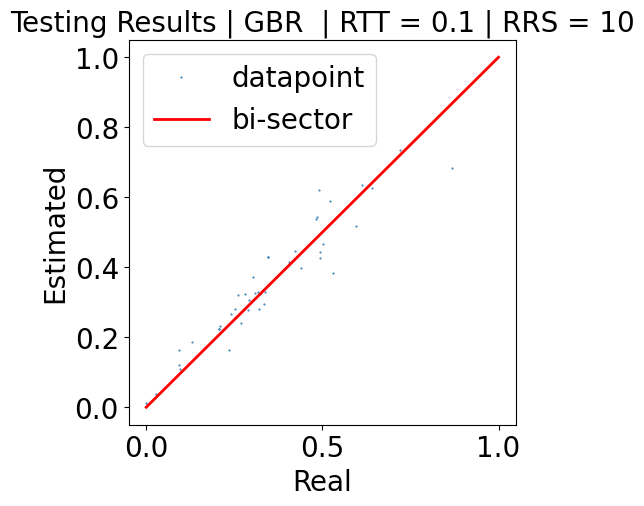

In [ ]:
#@title RTT Plots for 1 RRS for Gradient boosting
curr = result[0,9,4]
datain_tr_rtt1 = curr['datain_tr']
datain_te_rtt1 = curr['datain_te']
dataou_tr_rtt1 = curr['dataou_tr']
dataou_te_rtt1 = curr['dataou_te']
dataes_tr_rtt1 = curr['dataes_tr']
dataes_te_rtt1 = curr['dataes_te']

curr = result[1,9,4]
datain_tr_rtt2 = curr['datain_tr']
datain_te_rtt2 = curr['datain_te']
dataou_tr_rtt2 = curr['dataou_tr']
dataou_te_rtt2 = curr['dataou_te']
dataes_tr_rtt2 = curr['dataes_tr']
dataes_te_rtt2 = curr['dataes_te']


# plot training real vs estimation RTT 1
plt.figure(figsize=[5,5])
plt.plot(dataou_tr_rtt1, dataes_tr_rtt1, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Training Results | GBR  | RTT = 0.05 | RRS = 10', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)

# plot testing real vs estimation RTT 1
plt.figure(figsize=[5,5])
plt.plot(dataou_te_rtt1, dataes_te_rtt1, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Testing Results | GBR  | RTT = 0.05 | RRS = 10', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)


# plot training real vs estimation RTT 2
plt.figure(figsize=[5,5])
plt.plot(dataou_tr_rtt2, dataes_tr_rtt2, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Training Results | GBR  | RTT = 0.1 | RRS = 10', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)

# plot testing real vs estimation RTT 2
plt.figure(figsize=[5,5])
plt.plot(dataou_te_rtt2, dataes_te_rtt2, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Testing Results | GBR  | RTT = 0.1 | RRS = 10', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)


##########################################################
##########################################################
 
GBR Training MSE 0.0011026475589633548%
 
##########################################################
##########################################################


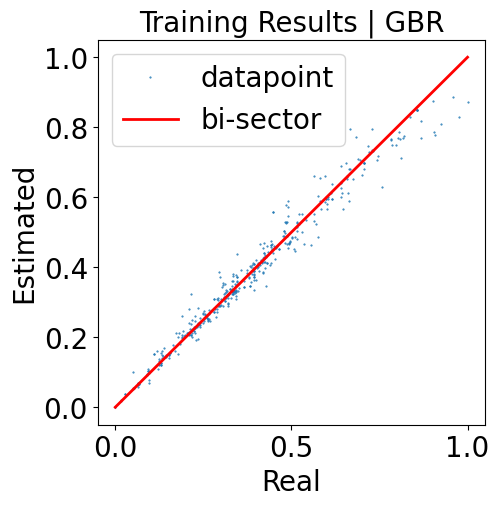

In [ ]:
#@title Develop Regressor 1

# Gradient Boosting Regressor selected as best model
# Create new scalein and scaleou objects, no dividing into train-test
# all data points are training data points

def fun_prep_train_all(datain, dataou, lb, ub):
  datain_tr = datain[:,:]
  dataou_tr = dataou[:,:]

  if len(datain_tr.shape) == 1:
    datain_tr = np.expand_dims(datain_tr, axis = 1)

  if len(dataou_tr.shape) == 1:
    dataou_tr = np.expand_dims(dataou_tr, axis = 1)

  scalerin = MinMaxScaler(feature_range=(lb,ub))
  scalerin.fit(datain_tr)

  scalerou = MinMaxScaler(feature_range=(lb,ub))
  scalerou.fit(dataou_tr)

  datain_tr_calibrated = scalerin.transform(datain_tr)
  dataou_tr_calibrated = scalerou.transform(dataou_tr)

  return datain_tr_calibrated, dataou_tr_calibrated, scalerin, scalerou



# Train GBR Model on All 425 Data Points from csv
gbr_model = gbr()
datain_tr_calibrated, dataou_tr_calibrated, scalerin, scalerou = (
    fun_prep_train_all(datain, dataou, 0, 1)
)

gbr_model.fit(datain_tr_calibrated, dataou_tr_calibrated)

dataes_tr_calibrated = gbr_model.predict(datain_tr_calibrated)
dataes_tr_calibrated = np.expand_dims(dataes_tr_calibrated, axis = 1)

print("##########################################################")
print("##########################################################")
print(" ")
print("GBR Training MSE {}%".format(mse(dataes_tr_calibrated,dataou_tr_calibrated)))
print(" ")
print("##########################################################")
print("##########################################################")

# plot training real vs estimation
plt.figure(figsize=[5,5])
plt.plot(dataou_tr_calibrated, dataes_tr_calibrated, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Training Results | GBR', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)

In [ ]:
#@title Get ACI Data
!wget https://raw.githubusercontent.com/mhrafiei/data/main/aci_based_mix.csv

--2026-08-13 00:46:19--  https://raw.githubusercontent.com/mhrafiei/data/main/aci_based_mix.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.108.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 444175 (434K) [text/plain]
Saving to: ‘aci_based_mix.csv’

aci_based_mix.csv   100%[===================>] 433.76K  --.-KB/s    in 0.1s    

2026-08-13 00:46:20 (3.34 MB/s) - ‘aci_based_mix.csv’ saved [444175/444175]



In [ ]:
#@title Process ACI Data
data_aci      = pd.read_csv('/content/aci_based_mix.csv')

# only 28-day concrete strength
data_aci = data_aci.iloc[:,1:]

# get all before first '(' for simplicity
data_aci_keys = list(data_aci.keys())
keys = []
for i0 in data_aci_keys:
  keys.append(i0[:i0.find('(')])

data_aci_in = data_aci.iloc[:,:]
data_aci_in = data_aci_in.values

# necessary information for combinatory model
num_data_aci      = data_aci_in.shape[0]
num_variables_aci = data_aci_in.shape[1]

print("\nFirst five rows:")
display(data_aci.head())

print("\nDataset information:")
data_aci.info()

# if len(data_aci_in.shape) == 1:
#   data_aci_in_tr = np.expand_dims(data_aci_in, axis = 1)

# fit scaler from previous processing
data_aci_in_calibrated = scalerin.transform(data_aci_in)


# Predict Compressive Strength for ACI set
data_aci_ou_calibrated = gbr_model.predict(data_aci_in_calibrated)
data_aci_ou_calibrated = np.expand_dims(data_aci_ou_calibrated, axis = 1)



First five rows:


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture)
0,410.87,0.00,0.00,213.83,0.0,951.15,803.78
1,243.66,123.07,0.00,206.93,0.0,1025.62,742.74
2,175.97,175.51,0.00,162.23,0.0,1095.57,784.37
3,315.37,0.00,91.47,233.30,0.0,951.67,766.44
4,229.94,190.85,0.00,259.36,0.0,870.83,655.85



Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9575 entries, 0 to 9574
Data columns (total 7 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   Cement (component 1)(kg in a m^3 mixture)              9575 non-null   float64
 1   Blast Furnace Slag (component 2)(kg in a m^3 mixture)  9575 non-null   float64
 2   Fly Ash (component 3)(kg in a m^3 mixture)             9575 non-null   float64
 3   Water  (component 4)(kg in a m^3 mixture)              9575 non-null   float64
 4   Superplasticizer (component 5)(kg in a m^3 mixture)    9575 non-null   float64
 5   Coarse Aggregate  (component 6)(kg in a m^3 mixture)   9575 non-null   float64
 6   Fine Aggregate (component 7)(kg in a m^3 mixture)      9575 non-null   float64
dtypes: float64(7)
memory usage: 523.8 KB


In [ ]:
#@title Boosted Data

# data_aci_in_calibrated, data_aci_ou_calibrated,  datain_tr_calibrated, dataou_tr_calibrated

datain_boosted = np.concatenate((datain_tr_calibrated, data_aci_in_calibrated), axis=0)
dataou_boosted = np.concatenate((dataou_tr_calibrated, data_aci_ou_calibrated), axis=0)

boosted_data_numpy_format = np.concatenate((datain_boosted, dataou_boosted), axis=1)

print("Input data shape: ", datain_boosted.shape)
print("Output data shape: ", dataou_boosted.shape)
print("Combined Input and Output data shape: ", boosted_data_numpy_format.shape)

Input data shape:  (10000, 7)
Output data shape:  (10000, 1)
Combined Input and Output data shape:  (10000, 8)


In [ ]:
#@title Install ctgan

# install ctgan
!pip install ctgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.5/75.5 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 17.6 MB/s eta 0:00:00


In [ ]:
#@title Super-Boosted Data

# Import the necessary libraries
# ctgan 0.10.1 as of May 2024
# A newer version of ctgan might require a new implementation
# Always read the documentation.
from ctgan import CTGAN

# Initialize the CTGAN model
ctgan = CTGAN(epochs=100)
# define the features
features = ['Cement(kg/m^3)',
'Blast Furnace Slag (kg/m^3)',
'Fly Ash (kg/m^3)',
'Water (kg/m^3)',
'Superplasticizer (kg/m^3)',
'Coarse Aggregate (kg/m^3)',
'Fine Aggregate (kg/m^3)']

# Assuming that you have boosted data in the numpy format (eight features; seven inputs and one output)
# They are obviously in the scaled domain.
boosted_input_data_tabular_format = pd.DataFrame(boosted_data_numpy_format[:,:-1],
columns = features)

# Fit the model to your data (usually should take less than 5 minutes)
ctgan.fit(boosted_input_data_tabular_format)

# Generate synthetic data
synthetic_data = ctgan.sample(40000)

Combined Data Shape:  (50000, 7)
Real Data Transformed Shape:  (10000, 2)
Generated Data Transformed Shape:  (40000, 2)


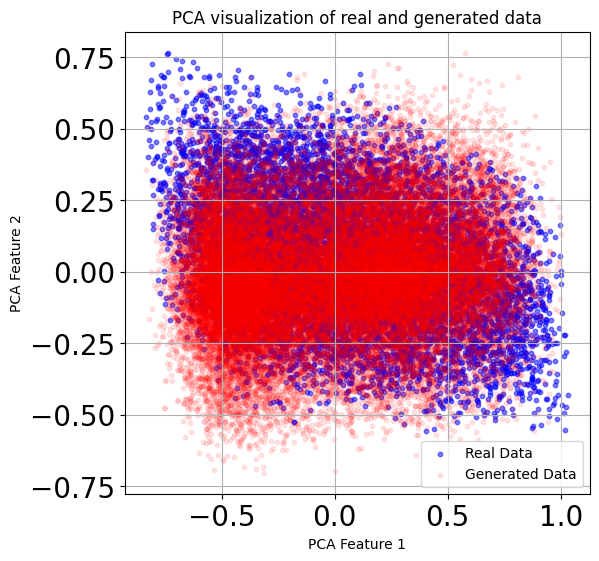

<Figure size 640x480 with 0 Axes>

In [ ]:
#@title Generate Plots
from sklearn.decomposition import PCA

# Combine real data and generated data
combined_data = np.vstack((boosted_data_numpy_format[:,:-1], synthetic_data.values))
print("Combined Data Shape: ", combined_data.shape)

# Apply PCA
method = 'PCA'
reducer = PCA(n_components=2)

reduced_data = reducer.fit_transform(combined_data)

# Split the reduced data back into real and generated
real_data_transformed = reduced_data[:10000]
generated_data_transformed = reduced_data[10000:]
print("Real Data Transformed Shape: ", real_data_transformed.shape)
print("Generated Data Transformed Shape: ", generated_data_transformed.shape)

# Plotting (feel free to adjust the alpha for better observation)
plt.figure(figsize=(6, 6))
plt.scatter(real_data_transformed[:, 0], real_data_transformed[:, 1], c='blue', s=10 , alpha=0.5, label='Real Data')
plt.scatter(generated_data_transformed[:, 0], generated_data_transformed[:, 1], s=10, c='red', alpha=0.1, label='Generated Data')
plt.title(f'{method} visualization of real and generated data')
plt.xlabel(f'{method} Feature 1')
plt.ylabel(f'{method} Feature 2')
plt.legend()
plt.grid(True)
plt.show()

# You may save the plot to be used later in your report.
plt.savefig("PCA_real_vs_generated.png")

In [ ]:
#@title Use Regressor 1 to Predict Outputs for Generated Data

# predict output for super boosted data using regressor 1 (gbr_model)
super_boosted_datain_calibrated = synthetic_data.values
super_boosted_dataou_calibrated = gbr_model.predict(super_boosted_datain_calibrated)
super_boosted_dataou_calibrated = np.expand_dims(super_boosted_dataou_calibrated, axis=1)

# combine inputs with predicted outputs
super_boosted_data_calibrated = np.concatenate((super_boosted_datain_calibrated,
                                                super_boosted_dataou_calibrated),
                                               axis=1)
print("Super boosted data shape: ", super_boosted_data_calibrated.shape)

# combine first 10000 points with super boosted points
all_data = np.concatenate((boosted_data_numpy_format,
                           super_boosted_data_calibrated),
                          axis=0)

print("All data shape: ", all_data.shape)

Super boosted data shape:  (40000, 8)
All data shape:  (50000, 8)


# Combinatory Investigation

In [ ]:
#@title Necessary Functions

def fun_combinations(num_data, num_variables):
  num_comb = 2**num_variables - 1
  comb_bin = np.zeros((num_comb,num_variables))
  comb_ind = []

  counter  = 0
  for i0 in range(num_variables):
    ind       = list(itertools.combinations(range(num_variables),i0+1))
    comb_ind.append(ind)

    for i1 in range(len(ind)):
      comb_bin[counter,ind[i1]] = 1
      counter                   = counter + 1

  comb_bin = comb_bin.astype(dtype = np.bool)

  return comb_bin, comb_ind, num_comb


def fun_prep_comb(datain, dataou, comb_bin, index_tr, index_te):
  datain_tr = datain[index_tr, :][:, comb_bin] # this way we avoid "mismatch" error in indexing
  datain_te = datain[index_te, :][:, comb_bin] # this way we avoid "mismatch" error in indexing
  dataou_tr = dataou[index_tr,:]
  dataou_te = dataou[index_te,:]

  if len(datain_tr.shape) == 1:
    datain_tr = np.expand_dims(datain_tr, axis = 1)
    datain_te = np.expand_dims(datain_te, axis = 1)

  if len(dataou_tr.shape) == 1:
    dataou_tr = np.expand_dims(dataou_tr, axis = 1)
    dataou_te = np.expand_dims(dataou_te, axis = 1)

  # not needed since super boosted data is already scaled
  # scalerin = MinMaxScaler(feature_range=(lb,ub))
  # scalerin.fit(datain_tr)

  # scalerou = MinMaxScaler(feature_range=(lb,ub))
  # scalerou.fit(dataou_tr)

  # datain_tr_calibrated = scalerin.transform(datain_tr)
  # datain_te_calibrated = scalerin.transform(datain_te)

  # dataou_tr_calibrated = scalerou.transform(dataou_tr)
  # dataou_te_calibrated = scalerou.transform(dataou_te)

  return datain_tr, dataou_tr, datain_te, dataou_te


In [ ]:
#@title Main Run
import warnings
warnings.filterwarnings("ignore")

# define RTT and RRS values
RTT        = [0.1]
RRS        = 5

# necessary information for combinatory model
num_data      = all_data.shape[0]
num_variables = all_data.shape[1] - 1

print("Number of data points: ", num_data)
print("Number of Variables: ", num_variables)

# split all data to define datain and dataou
datain_all = all_data[:, :-1]
dataou_all = all_data[:, -1:]

# generate combinations
comb_bin, _, num_comb = fun_combinations(num_data, num_variables)
index_tr, index_te           = fun_split(RTT, RRS, num_data)

result_comb = np.empty((len(RTT), RRS, num_comb), dtype = dict)

counter = 1
for i0 in range(num_comb):
  for i1 in range(len(RTT)):
    for i2 in range(RRS):
      datain_tr, dataou_tr, datain_te, dataou_te = fun_prep_comb(datain_all, dataou_all, comb_bin[i0,:], index_tr[i1][i2], index_te[i1][i2])
      result_comb[i1,i2,i0] = fun_ml(datain_tr, dataou_tr, datain_te, dataou_te, 'GDB')
      print("Comb #: {:05d}/{} | RTT #: {:05d}/{} | RRS #: {:05d}/{} | Completed {:07.3F}%".format(i0+1, num_comb, i1+1, len(RTT), i2+1, RRS, counter/(num_comb * len(RTT) * RRS) * 100))
      counter = counter + 1

Number of data points:  50000
Number of Variables:  7
Comb #: 00001/127 | RTT #: 00001/1 | RRS #: 00001/5 | Completed 000.157%
Comb #: 00001/127 | RTT #: 00001/1 | RRS #: 00002/5 | Completed 000.315%
Comb #: 00001/127 | RTT #: 00001/1 | RRS #: 00003/5 | Completed 000.472%
Comb #: 00001/127 | RTT #: 00001/1 | RRS #: 00004/5 | Completed 000.630%
Comb #: 00001/127 | RTT #: 00001/1 | RRS #: 00005/5 | Completed 000.787%
Comb #: 00002/127 | RTT #: 00001/1 | RRS #: 00001/5 | Completed 000.945%
Comb #: 00002/127 | RTT #: 00001/1 | RRS #: 00002/5 | Completed 001.102%
Comb #: 00002/127 | RTT #: 00001/1 | RRS #: 00003/5 | Completed 001.260%
Comb #: 00002/127 | RTT #: 00001/1 | RRS #: 00004/5 | Completed 001.417%
Comb #: 00002/127 | RTT #: 00001/1 | RRS #: 00005/5 | Completed 001.575%
Comb #: 00003/127 | RTT #: 00001/1 | RRS #: 00001/5 | Completed 001.732%
Comb #: 00003/127 | RTT #: 00001/1 | RRS #: 00002/5 | Completed 001.890%
Comb #: 00003/127 | RTT #: 00001/1 | RRS #: 00003/5 | Completed 002.04

In [ ]:
#@title Result Function
def fun_result(result, comb_bin):
  num_rtt, num_rrs, num_comb = result.shape
  result_summary                        = {}

  res_tr = np.empty((num_comb, 1))
  res_te = np.empty((num_comb, 1))

  for i0 in range(num_comb):

    mse_te = np.empty((num_rtt, num_rrs))
    mse_tr = np.empty((num_rtt, num_rrs))

    for i1 in range(num_rtt):
      for i2 in range(num_rrs):
        mse_tr[i1,i2] = result[i1, i2, i0]['mse_tr']
        mse_te[i1,i2] = result[i1, i2, i0]['mse_te']

    res_tr[i0,0] = mse_tr.mean()
    res_te[i0,0] = mse_te.mean()

  # sort combinations by training MSE
  mse_tr_sorted  = np.sort(res_tr, axis = 0)[:,0]
  mse_tr_index   = np.argsort(res_tr, axis = 0)[:,0]

  # sort combinations by testing MSE
  mse_te_sorted  = np.sort(res_te, axis = 0)[:,0]
  mse_te_index   = np.argsort(res_te, axis = 0)[:,0]

  result_summary = {'mse_tr&te'  : [mse_tr_sorted, res_te[mse_tr_index,0]],
                    'comb_bin_tr': comb_bin[mse_tr_index,:],
                    'mse_te&tr'  : [mse_te_sorted, res_tr[mse_te_index,0]],
                    'comb_bin_te': comb_bin[mse_te_index,:]}

  return result_summary

Best Combinations and Their Corresponding MSEs
----------------------------------------------
              Cement   Blast Furnace Slag   Fly Ash   Water    \
GDB Training        1                    1         1        1   
GDB Testing         1                    1         1        1   

              Superplasticizer   Coarse Aggregate    Fine Aggregate   \
GDB Training                  1                   1                1   
GDB Testing                   1                   1                1   

              MSE Training  MSE Testing  
GDB Training      0.000139     0.000169  
GDB Testing       0.000139     0.000169  


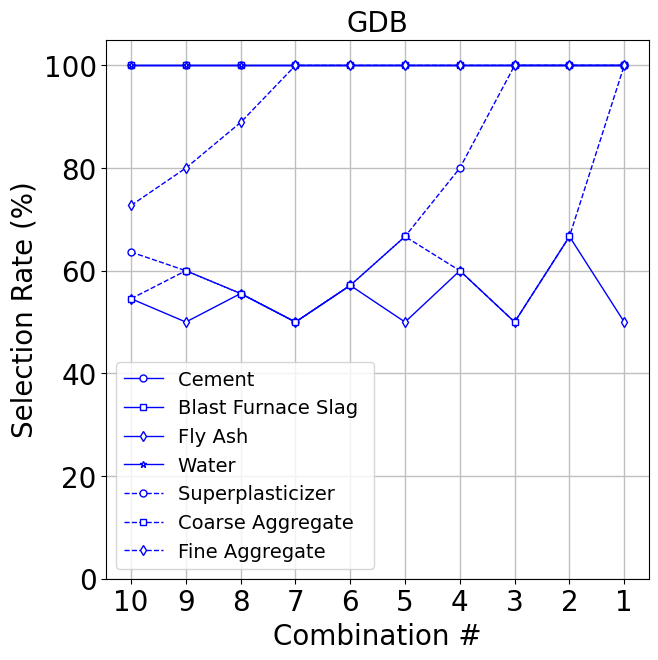

In [ ]:
#@title Results and summaries

result_summary = fun_result(result_comb, comb_bin)

#########################################
# Create a report about best combinations
#########################################
df = {}
# add combinations
for i0 in range(datain_all.shape[1]):
  comb_best = []

  comb_best_tr = result_summary['comb_bin_tr'][0,i0]*1
  comb_best_te = result_summary['comb_bin_te'][0,i0]*1

  comb_best.append(comb_best_tr)
  comb_best.append(comb_best_te)

  df[keys[i0]] = comb_best

# add mse and data frame index (i.e., row names)
index       = []
mse_best_tr = []
mse_best_te = []

mse_best_tr.append(result_summary['mse_tr&te'][0][0])
mse_best_te.append(result_summary['mse_tr&te'][1][0])

mse_best_tr.append(result_summary['mse_te&tr'][1][0])
mse_best_te.append(result_summary['mse_te&tr'][0][0])

index.append('GDB Training')
index.append('GDB Testing')

df['MSE Training'] = mse_best_tr
df['MSE Testing']  = mse_best_te

df = pd.DataFrame(df, index=index)
df.to_csv('report.csv')
print("Best Combinations and Their Corresponding MSEs")
print("----------------------------------------------")
print(df)

df_summary = df

#######################################
# Create a report about selection rates
#######################################
col_val    = ['bo-','bs-','bd-','b*-','bo--','bs--','bd--','b*--','bo:','bs:','bd:','b*:']

comb_cumsum = np.cumsum(result_summary['comb_bin_te']*1, axis = 0)
comb_denom  = np.repeat(np.expand_dims(np.array(range(1,comb_cumsum.shape[0]+1)), axis = 1), comb_cumsum.shape[1], axis = 1)
comb_rate   = comb_cumsum / comb_denom  * 100

# *************************************************************

filename = 'Selection_Rates_GDB.csv'
comb_dict = {}

# top 10% num
num_top    = 10
comb_label = []
for i2 in range(num_top,0,-1):
  comb_label.append(str(i2))

plt.figure(figsize = [7,7])
for i2 in range(len(keys)):
  comb_dict[keys[i2]] = comb_rate[:,i2]

  # plot top 10 selection rates
  plt.plot(comb_rate[range(num_top,0,-1),i2],
            col_val[i2],
            linewidth = 1,
            markersize = 5,
            markerfacecolor = 'w')

  plt.xlabel('Combination #', fontsize = 20)
  plt.ylabel('Selection Rate (%)', fontsize = 20)
  plt.title('GDB', fontsize = 20)
  plt.xticks(np.arange(num_top), np.arange(num_top,0,-1))
  plt.grid(color=[.75,.75,.75], linestyle='-', linewidth=1, which='both')
  plt.ylim([0,105])
  plt.legend(keys, fontsize = 14)

  #plt.xticks(list(range), ['January', 'February', 'March'],
  df = pd.DataFrame(comb_dict)
  df.to_csv(filename)

 
GBR Training MSE 0.0002814316436696209%
 


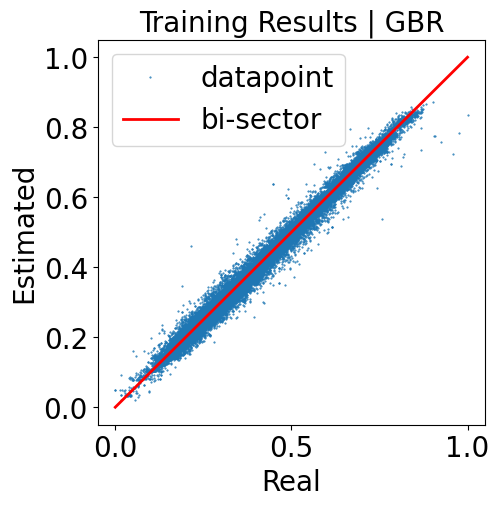

In [ ]:
#@title Develop Regressor 2


# Grab training super-boosted data, excluding fly ash and coarse aggregate due to earlier selection rate analysis
datain_reg2 = all_data[:,[0,1,3,4,6]]
dataou_reg2 = all_data[:,-1:]

# Gradient Boosting Regressor selected as best model
gbr_model_2 = gbr()
gbr_model_2.fit(datain_reg2, dataou_reg2)

dataes_reg2 = gbr_model_2.predict(datain_reg2)
dataes_reg2 = np.expand_dims(dataes_reg2, axis = 1)

print(" ")
print("GBR Training MSE {}%".format(mse(dataes_reg2,dataou_reg2)))
print(" ")


# plot training real vs estimation
plt.figure(figsize=[5,5])
plt.plot(dataou_reg2, dataes_reg2, '.', markersize = 1)
plt.plot([0,1],[0,1], '-r', linewidth = 2)
plt.xlabel('Real', fontsize = 20)
plt.ylabel('Estimated', fontsize = 20)
plt.title('Training Results | GBR', fontsize = 20)
plt.legend(['datapoint','bi-sector'], fontsize = 20)
matplotlib.rc('xtick', labelsize = 20)
matplotlib.rc('ytick', labelsize = 20)

In [ ]:
coarse_min = datain[:,5].min()
display(coarse_min.tolist())

801.0

In [ ]:
########################################################
#@title Optimization (Needed Functions)
#First unscale the super-boosted data for later use

datain_all_scaled = all_data[:,:-1]
dataou_all_scaled = all_data[:,-1:]

datain_all_original = scalerin.inverse_transform(datain_all_scaled)
dataou_all_original = scalerou.inverse_transform(dataou_all_scaled)



#In order to use scalerin/scalerou from part 3, need to retain all 7 features so inverse transforms can work.
#But, gbr_model_2 was trained with two features removed. Will have to be careful with formatting
# x will have fly ash and coarse aggregate information, but it will be removed temporarily in function for gbr

#Define function to change x into shape for scaling
def gbr_prep(x):
  new_x_arr = np.zeros(5);
  new_x_arr[0] = x[0]
  new_x_arr[1] = x[1]
  new_x_arr[2] = x[3]
  new_x_arr[3] = x[4]
  new_x_arr[4] = x[6]

  return new_x_arr.reshape(1, -1) # Return as a 2D array for compatibility with scalerin


#Define Objective Function
def fun_objective(x, gbr_model_2, scalerin, scalerou):
  #Determine scaled comp strength
  comp_strength_scaled = gbr_model_2.predict(gbr_prep(x))

  #Determine unscaled comp stregth
  comp_strength = scalerou.inverse_transform(comp_strength_scaled.reshape(1, -1))

  #Determine mixture weight
  x_unscaled = scalerin.inverse_transform(x.reshape(1, -1))
  mix_weight = np.sum(x_unscaled)

  # objective = comp_strength / mix_weight
  objective = -(comp_strength / mix_weight)


  return objective


#Define Constraints
#Recall from Pscipy.optimize.minimize that inequalities need to made to be positive

#Mix weight constraints
def fun_Weight_Min(x, gbr_model_2, scalerin, scalerou):
  x_unscaled = scalerin.inverse_transform(x.reshape(1, -1))
  mix_weight = np.sum(x_unscaled)

  min = mix_weight - 2300

  return min


def fun_Weight_Max(x, gbr_model_2, scalerin, scalerou):
  x_unscaled = scalerin.inverse_transform(x.reshape(1, -1))
  mix_weight = np.sum(x_unscaled)

  max = 2500 - mix_weight

  return max


#Water/Cement ratio cosntraint
def fun_WCR_Min(x, gbr_model_2, scalerin, scalerou):
  x_unscaled = scalerin.inverse_transform(x.reshape(1, -1))
  WCR = x_unscaled[0,3]/x_unscaled[0,0]

  min = WCR - 0.48

  return min


def fun_WCR_Max(x, gbr_model_2, scalerin, scalerou):
  x_unscaled = scalerin.inverse_transform(x.reshape(1, -1))
  WCR = x_unscaled[0,3]/x_unscaled[0,0]

  max = 0.59 - WCR

  return max


#Define Function to solve optimization
def fun_Solve_Optimization(gbr_model_2, scalerin, scalerou,i):
  #Constraint dictionaries
  INEQ_Con1    = {'type': 'ineq', 'fun': fun_Weight_Min, 'args': (gbr_model_2, scalerin, scalerou)}
  INEQ_Con2    = {'type': 'ineq', 'fun': fun_Weight_Max, 'args': (gbr_model_2, scalerin, scalerou)}
  INEQ_Con3    = {'type': 'ineq', 'fun': fun_WCR_Min, 'args': (gbr_model_2, scalerin, scalerou)}
  INEQ_Con4    = {'type': 'ineq', 'fun': fun_WCR_Max, 'args': (gbr_model_2, scalerin, scalerou)}

  #Constraint list
  constraint_all = ([INEQ_Con1, INEQ_Con2, INEQ_Con3, INEQ_Con4])

  #initial guess
  #NOTE: The minimization appears to be very sensitive to the initial guess, implying the space is non convex!
  #Running multiple times without a random seed preselected will get many different "optimal" combinations!
  # np.random.seed
  # x_initial = np.random.rand(7)

  best = None
  best_objective = np.inf

  num_starts = 1000

  for i in range(num_starts):
    x_initial = np.random.rand(7)

    result = minimize(fun_objective, x0 = x_initial, args=(gbr_model_2, scalerin, scalerou), method='SLSQP', constraints=constraint_all)

    if result.success:

      if result.fun < best_objective:
          best_objective = result.fun
          best = result

  #minimize call
  # return minimize(fun_objective, x0 = x_initial, args=(gbr_model_2, scalerin, scalerou), method='SLSQP', constraints=constraint_all)
  return best

In [ ]:
########################################################
#@title Testing

#Initial value:
final_mix_result = fun_Solve_Optimization(gbr_model_2, scalerin, scalerou,5)
print("Success:", final_mix_result.success)
print("Status:", final_mix_result.status)
print("Message:", final_mix_result.message)
print("Iterations:", final_mix_result.nit)
print("Objective:", final_mix_result.fun)
final_mix_scaled = final_mix_result.x
display(final_mix_scaled)
final_mix = scalerin.inverse_transform(final_mix_scaled.reshape(1,-1))
display(final_mix)
display(final_mix.sum())
final_strength = scalerou.inverse_transform(gbr_model_2.predict(gbr_prep(final_mix_scaled)).reshape(1,-1))
display(final_strength)






Success: True
Status: 0
Message: Optimization terminated successfully
Iterations: 2
Objective: -0.03145375433849158


array([0.49639866, 0.58643137, 0.235827  , 0.25178534, 0.79871512,
       0.21711346, 0.18538834])

array([[319.42261125, 210.76343581,  47.18898225, 153.32352444,
         25.71862671, 875.68702901, 667.89579056]])

np.float64(2300.000000030183)

array([[72.34363498]])